#### Import librairies

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import collections
import galsim

import tensorflow
import tensorflow as tf
import tensorflow_probability as tfp
import tensorflow.keras as keras
from tensorflow.keras import backend as K
tfd = tfp.distributions

sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.layers as layers
from tools_for_VAE import utils, vae_functions, generator, model
from tools_for_VAE.callbacks import changeAlpha

#import wandb
#from wandb.keras import WandbCallback

W0513 00:29:33.708952 139644508153664 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


##### Parameters

In [2]:
nb_of_bands = 6#1
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]#,128,256]#[32,64,128,256]#[8,16,32,64]#[32,64,128,256]#,128]#[32,64,128,256,512]
kernels = [3,3,3,3]#[3,3,3,3]##,3]

conv_activation = None
dense_activation = None

steps_per_epoch = int(10000/batch_size)
validation_steps = int(10000/batch_size)

bands = [0,1,2,3,4,5]

# With generator
#images_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/'
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/'#1_matching/'#deconv_conv_24.5/
list_of_samples = [[x for x in utils.listdir_fullpath(os.path.join(images_dir,'training_24.5_v2/')) if x.startswith(os.path.join(images_dir,'training_24.5_v2/')+'img_cropped_sample_')]][0]
list_of_samples_val = [[x for x in utils.listdir_fullpath(os.path.join(images_dir,'validation_24.5_v2/')) if x.startswith(os.path.join(images_dir,'validation_24.5_v2/')+'img_cropped_sample_')]][0]
#list_of_samples_test = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('img_sample.npy')]#mag_24.5
print(list_of_samples)
training_generator = generator.BatchGenerator_dc2_deconv_noisy(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

validation_generator = generator.BatchGenerator_dc2_deconv_noisy(bands,
                                    images_dir,
                                    list_of_samples_val, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='validation',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

test_generator = generator.BatchGenerator_dc2_deconv_noisy(bands, 
                                    images_dir,
                                    list_of_samples_val, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='validation',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

['/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_444.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_6.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_333.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_555.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_111.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_222.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_10.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_666.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_777.npy', '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/img_cropped_sample_1.npy']
[BatchGenerator] total_sample_size =  99887
[BatchGenerator] len(list_of_samples) =  10
[Batch

In [14]:
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [20]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/'

images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_1.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_1.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_1.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_1.csv')

images_noiseless_train = images_noiseless[:2000]
images_blend_train = images_blend[:2000]
psf_train = psf[:2000]

images_noiseless_val = images_noiseless[2000:2500]
images_blend_val = images_blend[2000:2500]
psf_val = psf[2000:2500]


ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])
   
ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])


ellipticity_1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence))
ellipticity_2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence))

e_train = np.zeros((2000,2))
e_train[:,0]=ellipticity_1[:2000]
e_train[:,1]=ellipticity_2[:2000]

e_val = np.zeros((500,2))
e_val[:,0]=ellipticity_1[2000:2500]
e_val[:,1]=ellipticity_2[2000:2500]

e_test = np.zeros((500,2))
e_test[:,0]=ellipticity_1[3000:3500]
e_test[:,1]=ellipticity_2[3000:3500]

In [4]:
print('construction OK')

#### Model definition

model_choice = 'wo_ls_concat_one'
# Without latent space
if model_choice == 'wo_ls_fft_moments':
    net = model.create_model_wo_ls_peak_pooling_fft_moments(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None) 
if model_choice == 'wo_ls_fft':
    net = model.create_model_wo_ls_peak_pooling_fft_2(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
if model_choice == 'wo_ls_dense':
    net = model.create_model_wo_ls_peak_pooling_dense(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
if model_choice == 'wo_ls_no_psf':
    net = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
if model_choice == 'wo_ls':
    net = model.create_model_wo_ls_peak_pooling(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
if model_choice == 'wo_ls_concat_one':
    net = model.create_model_wo_ls_peak_pooling_concat_one(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
    #net = model.create_model_shear(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
if model_choice == 'full_prob_flipout':
    net = model.create_model_prob_flipout_peak(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

net.summary()
net.layers[-1].trainable = False

#### Loss definition
alpha = K.variable(0.)

W0513 00:29:35.662244 139644508153664 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.


construction OK


W0513 00:29:36.112860 139644508153664 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 59, 59, 6)    24          input_1[0][0]                    
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 59, 59, 32)   1760        batch_normalization[0][0]        
______________________________________________________________________________________________

In [38]:
if model_choice == 'full_prob_rt' or model_choice == 'full_prob_flipout':
    kl = sum(net.losses)
    def loss(x, dists):
        nll = -dists.log_prob(x)
        print(nll)
        kl = sum(net.losses)
        print(kl)
        return nll + kl, collections.namedtuple('loss','nll,kl')(nll, kl)

    negative_log_likelihood = lambda x, rv_x: -rv_x.log_prob(x)+ kl *(K.get_value(alpha)-1)

else:

    negative_log_likelihood = lambda x, rv_x: -rv_x.log_prob(x)


# Custom metrics
def kl_metric(y_true, y_pred):
    return K.sum(net.losses)
mse = tf.keras.losses.MeanSquaredError()
hinge = tf.keras.losses.Hinge()
maepercent = tf.keras.losses.MeanAbsolutePercentageError()
mae = tf.keras.losses.MeanAbsoluteError()
mselog = tf.keras.losses.MeanSquaredLogarithmicError()

net.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4),
              loss=negative_log_likelihood,
              metrics = ['mse', 'acc',kl_metric],
             experimental_run_tf_function=False)


if ('noloading' == 'loading'):
    print('in loading')
    loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_test/loss/'
    print(loading_path)
    latest = tf.train.latest_checkpoint(loading_path)
    net.load_weights(latest)


# Callbacks
#saving_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'+str(sys.argv[2])
#checkpointer_mse = tf.keras.callbacks.ModelCheckpoint(filepath=saving_path+'/mse/weights_noisy_v4.{epoch:02d}-{val_mean_squared_error:.2f}.ckpt', monitor='val_mean_squared_error', verbose=1, save_best_only=True,save_weights_only=True, mode='min', period=1)#mse en TF2
#checkpointer_loss = tf.keras.callbacks.ModelCheckpoint(filepath=saving_path+'/loss/weights_noisy_v4.{epoch:02d}-{val_loss:.2f}.ckpt', monitor='val_loss', verbose=1, save_best_only=True,save_weights_only=True, mode='min', period=1)
#checkpointer_acc = tf.keras.callbacks.ModelCheckpoint(filepath=saving_path+'/acc/weights_noisy_v4.{epoch:02d}-{val_acc:.2f}.ckpt', monitor='val_acc', verbose=1, save_best_only=True,save_weights_only=True, mode='max', period=1)

#alpha_changer = changeAlpha(alpha, net,negative_log_likelihood, kl_metric)

#callbacks = [checkpointer_mse, checkpointer_loss]#, checkpointer_acc]#, alpha_changer]#, alpha_changer]#, WandbCallback()]#, alpha_changer]

In [39]:
batch_size

128

In [44]:
######## Train the network
## With dataset (faster than directly from generator)
hist = net.fit((images_blend_train, psf_train), e_train, epochs=1000,#training_ds
                    batch_size=batch_size,
                    verbose=1,
                    shuffle=True,
                    validation_data=((images_blend_val, psf_val), e_val),
                    validation_steps=5)

#saving_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'+str(sys.argv[2])
#net.save_weights(saving_path+'cp-{epoch:04d}.ckpt')

Train on 2000 samples, validate on 500 samples
Epoch 1/1000
2000/2000 [==============================] - 5s 2ms/sample - loss: 13.6331 - mean_squared_error: 0.0367 - acc: 0.8030 - kl_metric: 0.0000e+00 - val_loss: 20.9411 - val_mean_squared_error: 0.0528 - val_acc: 0.6988 - val_kl_metric: 0.0000e+00
Epoch 2/1000
2000/2000 [==============================] - 5s 2ms/sample - loss: 11.4122 - mean_squared_error: 0.0354 - acc: 0.8010 - kl_metric: 0.0000e+00 - val_loss: 18.7093 - val_mean_squared_error: 0.0529 - val_acc: 0.6868 - val_kl_metric: 0.0000e+00
Epoch 3/1000
2000/2000 [==============================] - 5s 2ms/sample - loss: 9.9573 - mean_squared_error: 0.0350 - acc: 0.7975 - kl_metric: 0.0000e+00 - val_loss: 16.7762 - val_mean_squared_error: 0.0506 - val_acc: 0.6944 - val_kl_metric: 0.0000e+00
Epoch 4/1000
2000/2000 [==============================] - 5s 2ms/sample - loss: 8.3466 - mean_squared_error: 0.0331 - acc: 0.7790 - kl_metric: 0.0000e+00 - val_loss: 15.0450 - val_mean_squared

KeyboardInterrupt: 

mean e2: 0.1462565 mean e2: 0.1602158


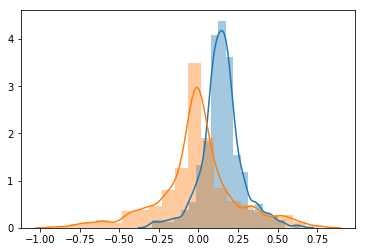

In [41]:
#### Plots
## REGENERER AVEC NOUVELLES IMAGES ET RENORMALISATION CORRECTE
#loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'+str(sys.argv[2])+'/loss/'#test_5
#latest = tf.train.latest_checkpoint(loading_path)
#net.load_weights(latest)
#test = test_generator.__getitem__(3)

training_data = (images_blend[3000:3500],psf[3000:3500])#[0], test[0][1]]
training_labels = e_test
#print(training_data.shape)
out = net([tf.cast(training_data[0], tf.float32), tf.cast(training_data[1], tf.float32)])# net(training_data) en TF2

print('mean e2: '+str(np.mean(K.get_value(out.mean())[:,0]))+' mean e2: '+str(np.mean(K.get_value(out.mean())[:,1])))

fig = plt.figure()
sns.distplot(K.get_value(out.mean())[:,0], bins = 20)# out.mean().numpy()
sns.distplot(training_labels[:,0], bins = 20)
#fig.savefig('full_prob/test_distrib_e1.png')

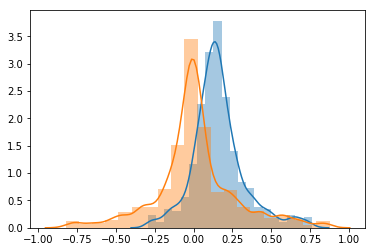

In [42]:
fig = plt.figure()
sns.distplot(K.get_value(out.mean())[:,1], bins = 20)# out.mean().numpy()
sns.distplot(training_labels[:,1], bins = 20)
#fig.savefig('full_prob/test_distrib_e2.png')

Text(0.5, 1.0, '$e2$')

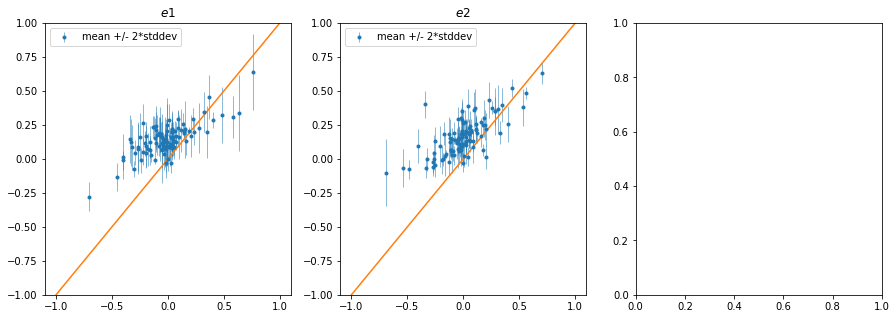

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nb_of_points = 100
axes[0].errorbar(training_labels[:nb_of_points,0], K.get_value(out.mean())[:nb_of_points,0], yerr = 2*K.get_value(out.stddev())[:nb_of_points,0],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-1,1)#(-1,1)#-0,5
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)#(-1,1)#-1,1
axes[0].set_title('$e1$')

axes[1].errorbar(training_labels[:nb_of_points,1], K.get_value(out.mean())[:nb_of_points,1], yerr = 2*K.get_value(out.stddev())[:nb_of_points,1],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-1,1)#(-1,1)#-1,1
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)#(-1,1)#-1,1
axes[1].set_title('$e2$')


#fig.savefig('full_prob/test_train.png')

In [37]:
##################################
# out = net([tf.cast(training_data[0], tf.float32), tf.cast(training_data[1], tf.float32)])
# fig = plt.figure()
# out = K.get_value(out)
# print(out.shape)
# sns.distplot(out[:,0], bins = 20, label = 'output')
# sns.distplot(training_labels[:,0], bins = 20, label = 'input')
# fig.savefig('full_prob/test_distrib_e1.png')


# fig = plt.figure()
# sns.distplot(out[:,1], bins = 20)
# sns.distplot(training_labels[:,1], bins = 20)
# fig.savefig('full_prob/test_distrib_e2.png')


# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0].plot(training_labels[:,0], out[:,0], '.', label = 'mean')
# x = np.linspace(-1,1)
# axes[0].plot(x, x)
# axes[0].legend()
# axes[0].set_ylim(-1,1)
# axes[0].set_title('$e1$')

# axes[1].plot(training_labels[:,1], out[:,1], '.', label = 'mean')
# x = np.linspace(-1,1)
# axes[1].plot(x, x)
# axes[1].legend()
# axes[1].set_ylim(-1,1)
# axes[1].set_title('$e2$')

# # axes[2].plot(y[:,2], out[:,2], '.', label = 'mean')
# # x = np.linspace(0,4)
# # axes[2].plot(x, x)
# # axes[2].legend()
# # axes[2].set_ylim(-1,5.5)
# # axes[2].set_title('$z$')

# fig.savefig('full_prob/test_train.png')